# Análisis exploratorio de los datos

Trabajo de fin de máster

Carlos Sanchiz Pérez

## Dependencias

In [ ]:
!pip install plotly

In [1]:
# Cargamos Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

## Carga de los datos

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TFM/AnalisisExploratorioDeLosDatos/pisos.csv", sep = ';')

In [ ]:
df.head()

,tipo,precio,localidad,latitud,longitud,superficie_construida,habitaciones,banyos,antiguedad,conservacion,...,jardin,orientacion,garaje,piscina,aire_acondicionado,trastero,ascensor,planta,fecha,detalle_url
0,Ático,70000,Alcoi Alcoy,38.700241,-0.481300,90.0,2.0,1.0,Entre 5 y 10 años,En buen estado,...,Desconocido,Desconocido,Desconocido,Sin piscina,False,True,False,5ª,2025-12-23,https://www.pisos.com/comprar/atico-alcoi_alco...
1,Piso,139000,Ibi,38.624174,-0.574839,120.0,4.0,1.0,Entre 30 y 50 años,En buen estado,...,Desconocido,Este,Desconocido,Sin piscina,False,True,True,4ª,2026-02-24,https://www.pisos.com/comprar/piso-ibi_centro_...
2,Ático,950000,Alicante Alacant,38.380730,-0.410119,100.0,3.0,2.0,Desconocida,A reformar,...,Comunitario,Sur-Este,Privado,Comunitaria,False,False,True,10ª,2026-02-02,https://www.pisos.com/comprar/atico-playas_pla...
3,Piso,200000,La Vila Joiosa Villajoyosa,38.502493,-0.241090,85.0,3.0,2.0,Entre 10 y 20 años,En buen estado,...,Privado,Desconocido,Desconocido,Sin piscina,True,True,True,0ª,2026-02-24,https://www.pisos.com/comprar/piso-montiboli_p...
4,Piso,115000,Alcoi Alcoy,38.691936,-0.488745,90.0,4.0,2.0,Desconocida,En buen estado,...,Desconocido,Desconocido,Privado,Sin piscina,False,True,True,0ª,NaN,https://www.pisos.com/comprar/piso-alcoi_alcoy...


## Análisis

### Tipo de vivienda

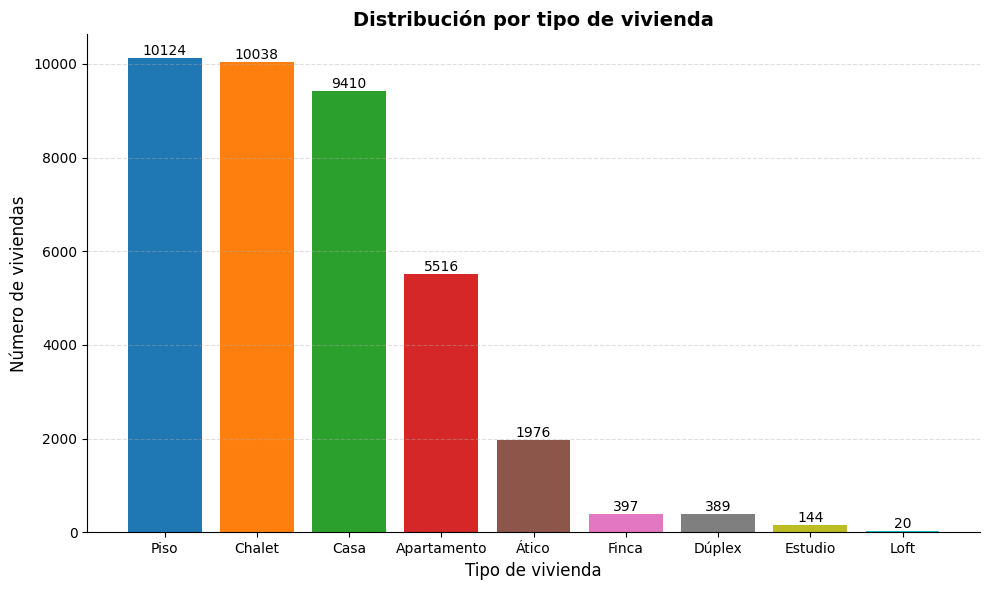

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conteo = df['tipo'].value_counts()

colors = plt.cm.tab10(np.linspace(0, 1, len(conteo)))

plt.figure(figsize=(10,6))
bars = plt.bar(conteo.index, conteo.values, color=colors)

plt.title('Distribución por tipo de vivienda', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de vivienda', fontsize=12)
plt.ylabel('Número de viviendas', fontsize=12)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Precio

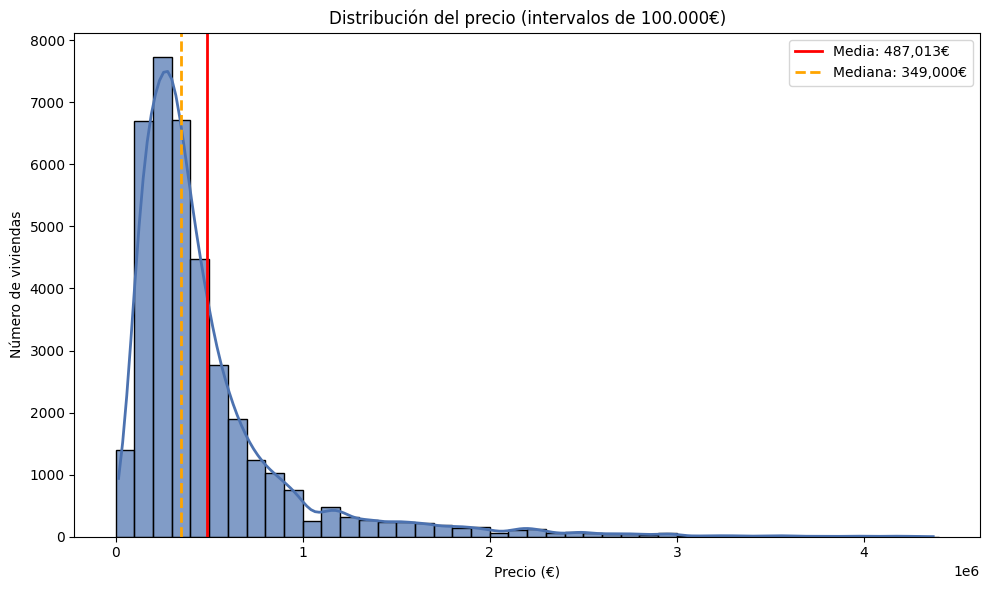

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bins = np.arange(0, df['precio'].max() + 100000, 100000)

# Calcular estadísticas
media = df['precio'].mean()
mediana = df['precio'].median()

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='precio',
    bins=bins,
    kde=True,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.7,
    line_kws={'color': 'green', 'linewidth': 2}
)

# Líneas verticales
plt.axvline(media, color='red', linestyle='-', linewidth=2, label=f'Media: {int(media):,}€')
plt.axvline(mediana, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {int(mediana):,}€')

# Etiquetas
plt.xlabel("Precio (€)")
plt.ylabel("Número de viviendas")
plt.title("Distribución del precio (intervalos de 100.000€)")

# Leyenda
plt.legend()

plt.tight_layout()
plt.show()

### Densidad de viviendas

In [ ]:
import plotly.express as px

fig = px.density_mapbox(
    df,
    lat="latitud",
    lon="longitud",
    radius=1,
    center={"lat": 38.3452, "lon": -0.4810},
    zoom=8,
    mapbox_style="open-street-map",
    height=700
)

fig.show()

In [ ]:
fig = px.density_mapbox(
    df,
    lat="latitud",
    lon="longitud",
    z="precio",
    radius=3,
    center={"lat": 38.3452, "lon": -0.4810},
    zoom=8,
    mapbox_style="open-street-map",
    height=700
)

fig.show()

### Precio del metro cuadrado

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

# Precio por metro cuadrado
df["precio_m2"] = df["precio"] / df["superficie_construida"]

# Eliminar valores no válidos
df_mapa = df[
    (df["precio_m2"] > 0) &
    (df["superficie_construida"] > 0) &
    df["latitud"].notna() &
    df["longitud"].notna()
].copy()

# Crear una cuadrícula
tamaño_celda = 0.02  # aproximadamente 2 km en latitud

df_mapa["lat_celda"] = (
    np.floor(df_mapa["latitud"] / tamaño_celda) * tamaño_celda
)

df_mapa["lon_celda"] = (
    np.floor(df_mapa["longitud"] / tamaño_celda) * tamaño_celda
)

# Calcular precio medio por m² en cada celda
cuadricula = (
    df_mapa
    .groupby(["lat_celda", "lon_celda"])
    .agg(
        precio_m2=("precio_m2", "mean"),
        viviendas=("precio_m2", "count")
    )
    .reset_index()
)

# Coordenadas del centro de cada celda
cuadricula["latitud"] = cuadricula["lat_celda"] + tamaño_celda / 2
cuadricula["longitud"] = cuadricula["lon_celda"] + tamaño_celda / 2

# Mapa
fig = px.scatter_mapbox(
    cuadricula,
    lat="latitud",
    lon="longitud",
    color="precio_m2",
    size="viviendas",
    size_max=25,
    zoom=8,
    center={"lat": 38.3452, "lon": -0.4810},
    mapbox_style="open-street-map",
    height=700,
    color_continuous_scale="Turbo",
    labels={
        "precio_m2": "Precio medio (€/m²)",
        "viviendas": "N.º de viviendas"
    },
    hover_data={
        "precio_m2": ":.0f",
        "viviendas": True
    }
)

fig.show()

In [ ]:
fig = px.scatter_mapbox(
    cuadricula,
    lat="latitud",
    lon="longitud",
    color="precio_m2",
    size="viviendas",
    size_max=25,
    zoom=8,
    center={"lat": 38.3452, "lon": -0.4810},
    mapbox_style="open-street-map",
    height=700,
    color_continuous_scale="Turbo",
    range_color=[0, 5000],
    labels={
        "precio_m2": "Precio medio (€/m²)",
        "viviendas": "N.º de viviendas"
    },
    hover_data={
        "precio_m2": ":.0f",
        "viviendas": True
    }
)

fig.show()

In [ ]:
fig = px.scatter_mapbox(
    cuadricula,
    lat="latitud",
    lon="longitud",
    color="precio_m2",
    zoom=8,
    center={"lat": 38.3452, "lon": -0.4810},
    mapbox_style="open-street-map",
    height=700,
    width=900,
    color_continuous_scale=[
    [0, "#2E7D32"],
    [0.5, "#FDD835"],
    [1, "#C62828"]
],
    range_color=[0, 5000],
    labels={
        "precio_m2": "Precio medio (€/m²)",
        "viviendas": "N.º de viviendas"
    },
    hover_data={
        "precio_m2": ":.0f",
        "viviendas": True
    }
)

fig.show()

### Habitaciones vs Baños

/tmp/ipykernel_426/1452106291.py:24: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



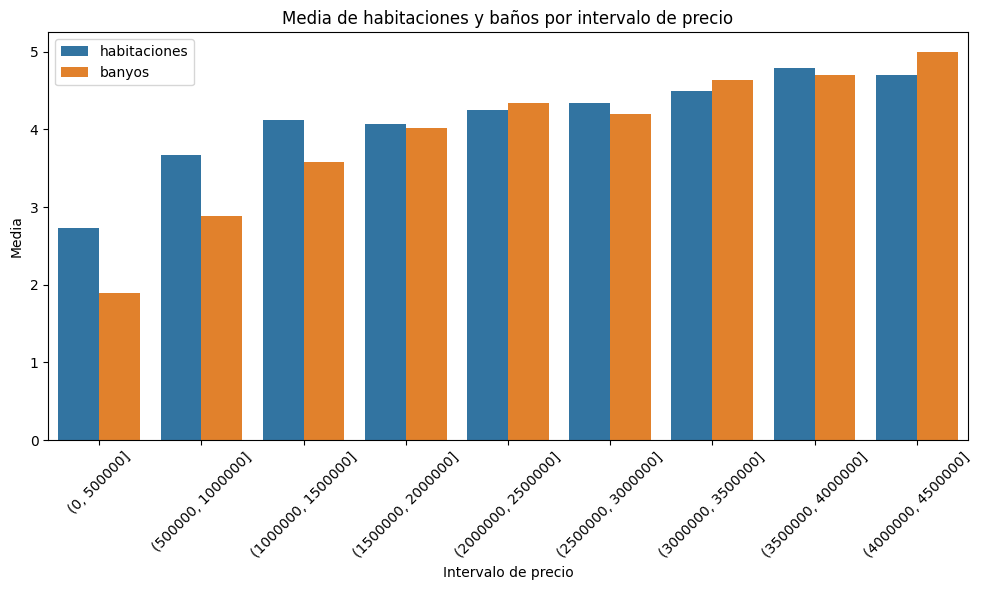

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Definir límites de los intervalos
min_precio = df["precio"].min()
max_precio = df["precio"].max()

bins = np.arange(
    0,
    max_precio + 500000,
    500000
)

# 2️⃣ Crear intervalos
df["intervalo_precio"] = pd.cut(
    df["precio"],
    bins=bins
)

# 3️⃣ Agrupar y calcular medias
resumen = (
    df
    .groupby("intervalo_precio")[["habitaciones", "banyos"]]
    .mean()
    .reset_index()
)

# 4️⃣ Formato largo
df_plot = resumen.melt(
    id_vars="intervalo_precio",
    value_vars=["habitaciones", "banyos"],
    var_name="tipo",
    value_name="media"
)

# 5️⃣ Gráfico
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_plot,
    x="intervalo_precio",
    y="media",
    hue="tipo"
)

plt.xticks(rotation=45)
plt.xlabel("Intervalo de precio")
plt.ylabel("Media")
plt.title("Media de habitaciones y baños por intervalo de precio")
plt.legend(title="")
plt.tight_layout()
plt.show()

/tmp/ipykernel_620/2720533763.py:24: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



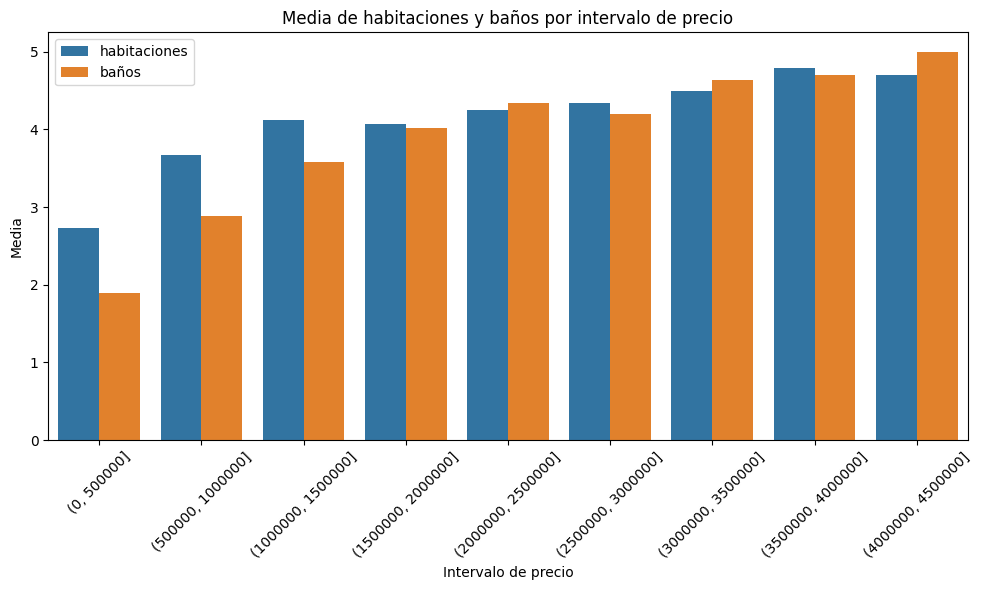

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Definir límites de los intervalos
min_precio = df["precio"].min()
max_precio = df["precio"].max()

bins = np.arange(
    0,
    max_precio + 500000,
    500000
)

# 2️⃣ Crear intervalos
df["intervalo_precio"] = pd.cut(
    df["precio"],
    bins=bins
)

# 3️⃣ Agrupar y calcular medias
resumen = (
    df
    .groupby("intervalo_precio")[["habitaciones", "baños"]]
    .mean()
    .reset_index()
)

# 4️⃣ Formato largo
df_plot = resumen.melt(
    id_vars="intervalo_precio",
    value_vars=["habitaciones", "baños"],
    var_name="tipo",
    value_name="media"
)

# 5️⃣ Gráfico
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_plot,
    x="intervalo_precio",
    y="media",
    hue="tipo"
)

plt.xticks(rotation=45)
plt.xlabel("Intervalo de precio")
plt.ylabel("Media")
plt.title("Media de habitaciones y baños por intervalo de precio")
plt.legend(title="")
plt.tight_layout()
plt.show()

### Matriz de correlación

                         precio  superficie construida  habitaciones  \
precio                 1.000000               0.657192      0.389817   
superficie construida  0.657192               1.000000      0.659551   
habitaciones           0.389817               0.659551      1.000000   
baños                  0.646337               0.674714      0.589431   
conservación           0.057011               0.015029     -0.000296   
antigüedad            -0.047989              -0.010434      0.040856   
planta                -0.198889              -0.331482     -0.318278   

                          baños  conservación  antigüedad    planta  
precio                 0.646337      0.057011   -0.047989 -0.198889  
superficie construida  0.674714      0.015029   -0.010434 -0.331482  
habitaciones           0.589431     -0.000296    0.040856 -0.318278  
baños                  1.000000      0.044618   -0.080813 -0.276368  
conservación           0.044618      1.000000    0.036126  0.046510  
ant

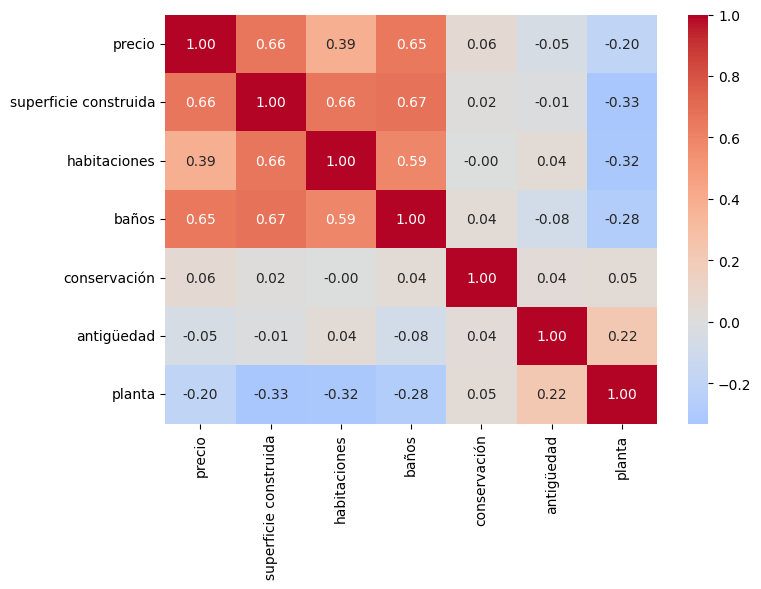

In [4]:
import pandas as pd
import numpy as np

df = df.rename(columns={
    'superficie_construida': 'superficie construida',
    'banyos': 'baños',
    'conservacion': 'conservación',
    'antiguedad': 'antigüedad'
})

# Copia de las variables que queremos transformar
df_correlacion = df[['precio', 'superficie construida', 'habitaciones', 'baños', 'conservación', 'antigüedad', 'planta']].copy()


# =========================
# ANTIGÜEDAD
# =========================

orden_antiguedad = [
    'Menos de 5 años',
    'Entre 5 y 10 años',
    'Entre 10 y 20 años',
    'Entre 20 y 30 años',
    'Entre 30 y 50 años',
    'Más de 50 años',
    'Desconocida'
]

df_correlacion['antigüedad'] = pd.Categorical(
    df_correlacion['antigüedad'],
    categories=orden_antiguedad,
    ordered=True
).codes


# =========================
# CONSERVACIÓN
# =========================

orden_conservacion = [
    'A estrenar',
    'Reformado',
    'En buen estado',
    'A reformar',
    'Desconocida'
]

df_correlacion['conservación'] = pd.Categorical(
    df_correlacion['conservación'],
    categories=orden_conservacion,
    ordered=True
).codes


# =========================
# PLANTA
# =========================

orden_planta = [
    'Sótano',
    '0ª',
    '1ª',
    '2ª',
    '3ª',
    '4ª',
    '5ª',
    '6ª',
    '7ª',
    '8ª',
    '9ª',
    '10ª',
    '11ª',
    '12ª',
    '13ª',
    '14ª',
    '15ª',
    '16ª',
    '17ª',
    '18ª',
    '19ª',
    '20ª',
    'Más de 20',
    'Desconocida'
]

df_correlacion['planta'] = pd.Categorical(
    df_correlacion['planta'],
    categories=orden_planta,
    ordered=True
).codes

df_correlacion['antigüedad'] = df_correlacion['antigüedad'].replace(-1, np.nan)
df_correlacion['conservación'] = df_correlacion['conservación'].replace(-1, np.nan)
df_correlacion['planta'] = df_correlacion['planta'].replace(-1, np.nan)

matriz_correlacion = df_correlacion.corr()

print(matriz_correlacion)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.tight_layout()
plt.show()

### Antigüedad VS Conservación

In [ ]:
df = df.rename(columns={
    'superficie_construida': 'superficie construida',
    'banyos': 'baños',
    'conservacion': 'conservación',
    'antiguedad': 'antigüedad'
})

df_temp = df[df["antigüedad"] != "Desconocida"]
df_temp = df_temp[df_temp["conservación"] != "Desconocida"]

print("Filas que tiene nuestro nuevo conjunto de datos: ", df_temp.shape[0])

orden_antiguedad = [
    "Menos de 5 años",
    "Entre 5 y 10 años",
    "Entre 10 y 20 años",
    "Entre 20 y 30 años",
    "Entre 30 y 50 años",
    "Más de 50 años"
]

orden_conservacion = [
    "A estrenar",
    "En buen estado",
    "Reformado",
    "A reformar"
]

tabla = pd.crosstab(
    df_temp["antigüedad"],
    df_temp["conservación"]
)

tabla = tabla.reindex(
    index=orden_antiguedad,
    columns=orden_conservacion
)

tabla

Filas que tiene nuestro nuevo conjunto de datos:  3030


conservación,A estrenar,En buen estado,Reformado,A reformar
antigüedad,,,,
Menos de 5 años,319,265,5,1
Entre 5 y 10 años,3,115,14,0
Entre 10 y 20 años,14,449,46,10
Entre 20 y 30 años,7,592,52,27
Entre 30 y 50 años,6,561,64,63
Más de 50 años,2,269,35,111


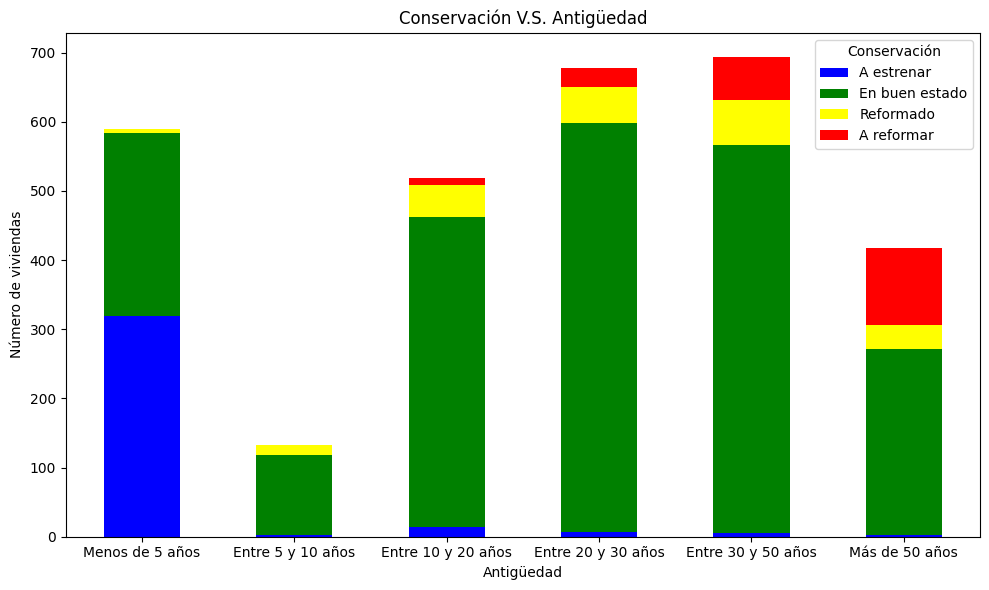

In [ ]:
colores = {
    "A estrenar": "blue",
    "En buen estado": "green",
    "Reformado": "yellow",
    "A reformar": "red"
}

tabla.plot(
    kind="bar",
    stacked=True,
    color=[colores[col] for col in tabla.columns],
    figsize=(10, 6)
)

plt.title('Conservación V.S. Antigüedad')
plt.xlabel("Antigüedad")
plt.ylabel("Número de viviendas")
plt.xticks(rotation=0)
plt.legend(title="Conservación")
plt.tight_layout()
plt.show()

In [ ]:
# Convertir cada fila a porcentajes
tabla_porcentaje = tabla.div(tabla.sum(axis=1), axis=0) * 100

tabla_porcentaje

conservación,A estrenar,En buen estado,Reformado,A reformar
antigüedad,,,,
Menos de 5 años,54.067797,44.915254,0.847458,0.169492
Entre 5 y 10 años,2.272727,87.121212,10.606061,0.000000
Entre 10 y 20 años,2.697495,86.512524,8.863198,1.926782
Entre 20 y 30 años,1.032448,87.315634,7.669617,3.982301
Entre 30 y 50 años,0.864553,80.835735,9.221902,9.077810
Más de 50 años,0.479616,64.508393,8.393285,26.618705


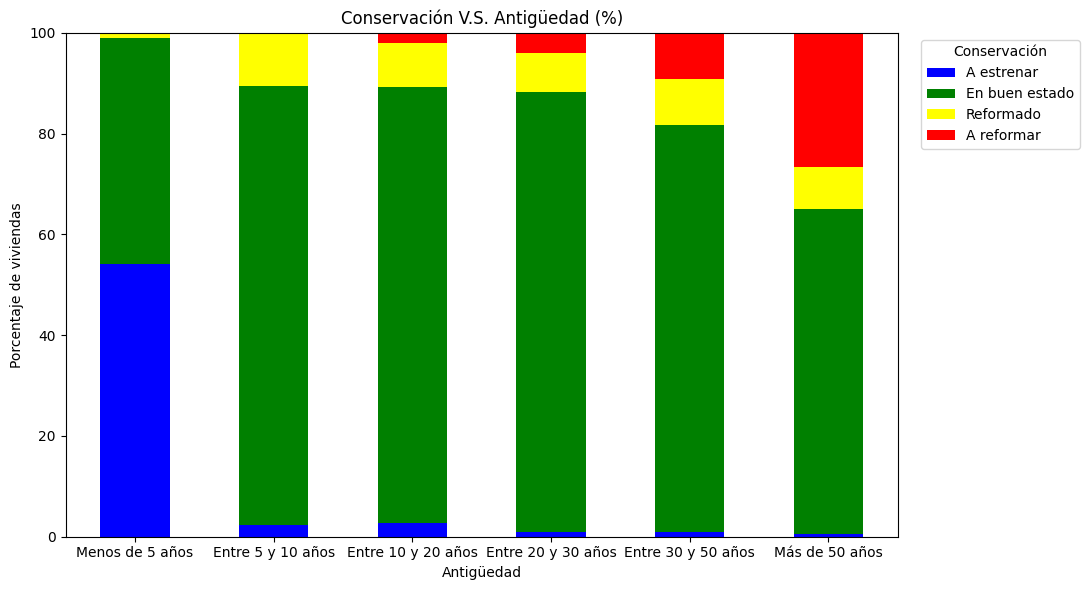

In [ ]:
colores = {
    "A estrenar": "blue",
    "En buen estado": "green",
    "Reformado": "yellow",
    "A reformar": "red"
}

tabla_porcentaje.plot(
    kind="bar",
    stacked=True,
    color=[colores[col] for col in tabla_porcentaje.columns],
    figsize=(11, 6)
)

plt.title('Conservación V.S. Antigüedad (%)')
plt.xlabel("Antigüedad")
plt.ylabel("Porcentaje de viviendas")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(
    title="Conservación",
    bbox_to_anchor=(1.02, 1),
    loc="upper left")
plt.tight_layout()
plt.show()

### Ascensor vs Num plantas

In [ ]:
# Extraer el número de la planta
df_temp = df.copy()

df_temp = df_temp[df_temp['planta'].isin(['0ª', '1ª', '2ª', '3ª', '4ª', '5ª'])]
df_temp = df_temp[df_temp['tipo'].isin(['Ático', 'Piso', 'Apartamento'])]

df_temp["planta_num"] = (
    df_temp["planta"]
    .str.replace("ª", "", regex=False)
    .astype(int)
)

# Quedarnos con las plantas 0 a 5
df_temp = df_temp[df_temp["planta_num"].between(0, 5)]

# Tabla de frecuencias
tabla_ascensor = pd.crosstab(
    df_temp["planta_num"],
    df_temp["ascensor"]
)

# Asegurar que aparecen todas las plantas de 0 a 5
tabla_ascensor = tabla_ascensor.reindex(range(0, 6), fill_value=0)

tabla_ascensor

tabla_ascensor_pct = tabla_ascensor.div(
    tabla_ascensor.sum(axis=1),
    axis=0
) * 100

tabla_ascensor_pct

ascensor,False,True
planta_num,,
0,44.495151,55.504849
1,34.414081,65.585919
2,31.954887,68.045113
3,28.826531,71.173469
4,24.825175,75.174825
5,13.934426,86.065574


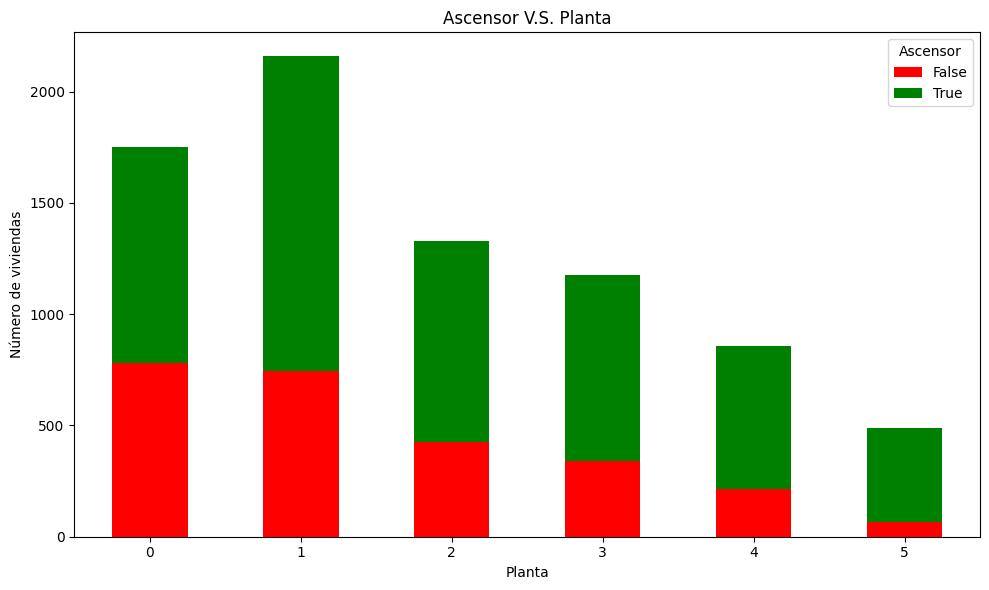

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Gráfico de barras apiladas
tabla_ascensor.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=['red', 'green']
)

plt.title('Ascensor V.S. Planta')
plt.xlabel("Planta")
plt.ylabel("Número de viviendas")
plt.xticks(rotation=0)
plt.legend(title="Ascensor")
plt.tight_layout()
plt.show()

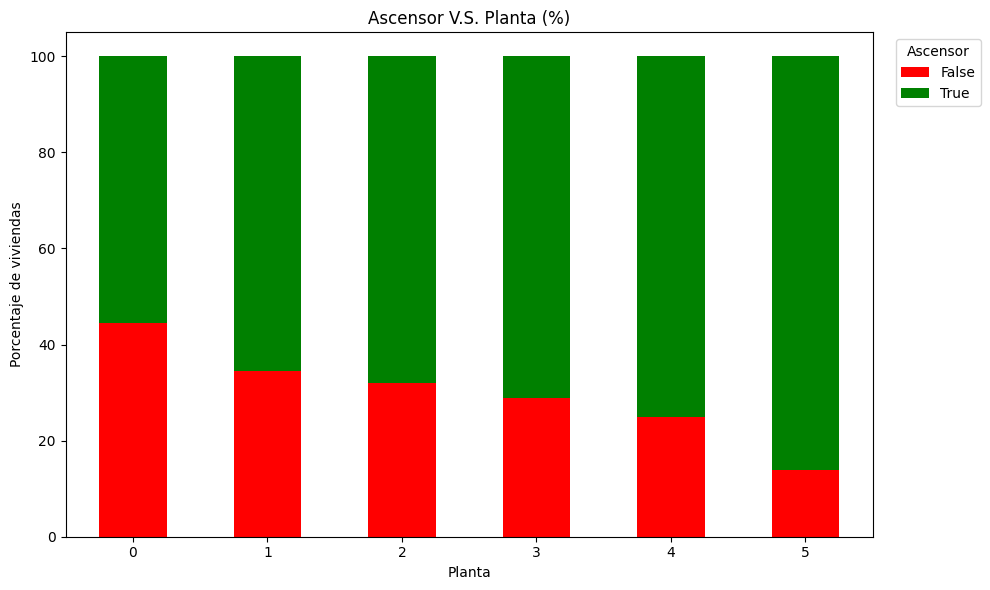

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

tabla_ascensor_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=['red', 'green']
)

plt.title('Ascensor V.S. Planta (%)')
plt.xlabel("Planta")
plt.ylabel("Porcentaje de viviendas")
plt.xticks(rotation=0)

plt.legend(
    title="Ascensor",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()